# CASHACCESS-LU — Empirical Analysis

## Research question

**How geographically accessible is physical cash infrastructure in Luxembourg, how is accessibility distributed across population and municipalities, and how vulnerable is access to changes in cash infrastructure?**

This notebook uses the **validated downloaded datasets** produced by the CASHACCESS-LU downloader.

### Inputs

- `data/luxembourg_communes.gpkg`
- `data/luxembourg_1km_reference_grid.gpkg`
- `data/population_grid_1km_2021.gpkg`
- `data/cash_points_current.gpkg`
- `data/luxembourg_drive_network.graphml`
- `data/bcl_ecb_atm_counts.csv`

### Core analyses

1. Data and geometry validation
2. All-cash-access and ATM-only accessibility
3. Population-weighted distance metrics
4. Population coverage thresholds
5. Accessibility inequality
6. Commune-level aggregation
7. Cash infrastructure spatial distribution
8. ECB ATM time trend
9. Global and local spatial autocorrelation
10. Exploratory spatial econometrics
11. Road-network accessibility
12. ATM/infrastructure closure resilience
13. Identification of vulnerable communes
14. Research-ready exports

### Important interpretation rule

This is initially an **observational/descriptive and exploratory spatial study**. It does not establish that any infrastructure characteristic *causes* accessibility outcomes. 

In [ ]:


from pathlib import Path
import warnings
import os
import json
import math

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import networkx as nx
import osmnx as ox

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LUREF_EPSG = 2169
WGS84_EPSG = 4326

print("CASHACCESS-LU empirical analysis")
print("Working directory:", Path.cwd())
print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())


CASHACCESS-LU empirical analysis
Working directory: f:\Finatrax Univ of lux
Data directory: F:\Finatrax Univ of lux\data
Output directory: F:\Finatrax Univ of lux\outputs


In [ ]:
 # 1. LOAD VALIDATED DATA
 
FILES = {
    "communes": DATA_DIR / "luxembourg_communes.gpkg",
    "reference_grid": DATA_DIR / "luxembourg_1km_reference_grid.gpkg",
    "population": DATA_DIR / "population_grid_1km_2021.gpkg",
    "cash": DATA_DIR / "cash_points_current.gpkg",
    "graph": DATA_DIR / "luxembourg_drive_network.graphml",
    "ecb": DATA_DIR / "bcl_ecb_atm_counts.csv",
}

for name, path in FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {name} file: {path}")

communes = gpd.read_file(FILES["communes"]).to_crs(LUREF_EPSG)
reference_grid = gpd.read_file(FILES["reference_grid"]).to_crs(LUREF_EPSG)
population = gpd.read_file(FILES["population"]).to_crs(LUREF_EPSG)
cash = gpd.read_file(FILES["cash"]).to_crs(LUREF_EPSG)
G = ox.load_graphml(FILES["graph"])
ecb_atm = pd.read_csv(FILES["ecb"])

print(f"Communes: {len(communes):,}")
print(f"Reference-grid cells: {len(reference_grid):,}")
print(f"Population-grid cells: {len(population):,}")
print(f"Cash-access points: {len(cash):,}")
print(f"Road nodes: {len(G.nodes):,}")
print(f"Road edges: {len(G.edges):,}")
print(f"ECB ATM observations: {len(ecb_atm):,}")


Communes: 100
Reference-grid cells: 2,937
Population-grid cells: 2,795
Cash-access points: 332
Road nodes: 23,529
Road edges: 54,544
ECB ATM observations: 26


In [ ]:
 # 2. INPUT VALIDATION  

assert len(communes) == 100, len(communes)
assert len(reference_grid) == 2937, len(reference_grid)
assert len(population) == 2795, len(population)

assert "COMMUNE" in communes.columns
assert "Population" not in population.columns or "Population" in population.columns
assert "population_2021" in population.columns

population["population_2021"] = pd.to_numeric(
    population["population_2021"], errors="coerce"
).fillna(0)

assert 600000 < population["population_2021"].sum() < 700000
assert cash.geometry.notna().all()

print("✓ Input validation passed")
print(f"✓ 2021 population represented: {population['population_2021'].sum():,.0f}")
print(f"✓ CRS: {population.crs}")


✓ Input validation passed
✓ 2021 population represented: 643,420
✓ CRS: EPSG:2169


In [ ]:
 
# 3. CASH-POINT CLASSIFICATION
 if "facility_type" not in cash.columns:
    def classify_cash_point(row):
        amenity = str(row.get("amenity", "")).lower()
        name = str(row.get("name", "")).lower()

        if amenity == "atm":
            return "ATM"
        if amenity == "bank":
            return "Bank branch"
        if amenity == "post_office":
            return "Post office"
        if "atm" in name:
            return "ATM"
        if "bank" in name or "banque" in name:
            return "Bank branch"
        if "post" in name or "poste" in name:
            return "Post office"
        return "Other"

    cash["facility_type"] = cash.apply(classify_cash_point, axis=1)

print(cash["facility_type"].value_counts())

atm = cash[cash["facility_type"] == "ATM"].copy()

print(f"All physical cash-access points: {len(cash):,}")
print(f"ATM-only points: {len(atm):,}")


facility_type
Bank branch    148
ATM            139
Post office     45
Name: count, dtype: int64
All physical cash-access points: 332
ATM-only points: 139


# 4. Population-grid centroids

The official 2,795-cell population grid is the master population exposure layer.

For accessibility calculations, each population cell is represented by its projected polygon centroid. Distances are then measured in metres because the layer is in **LUREF EPSG:2169**.


In [ ]:

luxembourg_geometry = communes.geometry.union_all()

pop_analysis = population.copy()

pop_analysis["analysis_geometry"] = (
    pop_analysis.geometry
    .make_valid()
    .intersection(luxembourg_geometry)
)

# Count cells with no Luxembourg-area geometry.
empty_analysis_geometry = (
    pop_analysis["analysis_geometry"].is_empty
    | pop_analysis["analysis_geometry"].isna()
)

print(
    "Population cells with usable Luxembourg geometry:",
    (~empty_analysis_geometry).sum(),
    "/",
    len(pop_analysis)
)

# Using a representative point 
pop_centroids = pop_analysis.loc[
    ~empty_analysis_geometry
].copy()

pop_centroids["geometry"] = (
    pop_centroids["analysis_geometry"]
    .representative_point()
)

pop_centroids = gpd.GeoDataFrame(
    pop_centroids,
    geometry="geometry",
    crs=LUREF_EPSG
)

print(
    f"Population analysis points: {len(pop_centroids):,}"
)

Population cells with usable Luxembourg geometry: 2794 / 2795
Population analysis points: 2,794


# PART I — Current physical cash accessibility

We first calculate **straight-line distance to the nearest physical cash-access point**, then repeat the calculation for **ATMs only**.




In [ ]:

nearest_all = gpd.sjoin_nearest(
    pop_centroids[["geometry"]],
    cash[["facility_type", "geometry"]],
    how="left",
    distance_col="distance_all_m"
)

nearest_all_min = (
    nearest_all.groupby(nearest_all.index)["distance_all_m"].min()
)

population["distance_all_m"] = population.index.map(nearest_all_min)
population["distance_all_km"] = population["distance_all_m"] / 1000

print(population["distance_all_km"].describe())


count    2794.000000
mean        3.058553
std         1.897666
min         0.006586
25%         1.615965
50%         2.796850
75%         4.171115
max        11.787036
Name: distance_all_km, dtype: float64


In [ ]:
 #NEAREST ATM
if len(atm) == 0:
    raise RuntimeError("No ATM points found in cash dataset.")

nearest_atm = gpd.sjoin_nearest(
    pop_centroids[["geometry"]],
    atm[["facility_type", "geometry"]],
    how="left",
    distance_col="distance_atm_m"
)

nearest_atm_min = (
    nearest_atm.groupby(nearest_atm.index)["distance_atm_m"].min()
)

population["distance_atm_m"] = population.index.map(nearest_atm_min)
population["distance_atm_km"] = population["distance_atm_m"] / 1000

print(population["distance_atm_km"].describe())


count    2794.000000
mean        3.610994
std         2.213067
min         0.006586
25%         1.937358
50%         3.293256
75%         4.849936
max        13.891816
Name: distance_atm_km, dtype: float64


In [ ]:
# POPULATION-WEIGHTED NATIONAL METRICS

def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    mask = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights >= 0)
    )

    if mask.sum() == 0 or weights[mask].sum() == 0:
        return np.nan

    return np.average(
        values[mask],
        weights=weights[mask]
    )


def weighted_median(values, weights):
    """
    True population-weighted median.
    """

    df = pd.DataFrame({
        "value": np.asarray(values, dtype=float),
        "weight": np.asarray(weights, dtype=float)
    })

    df = df[
        np.isfinite(df["value"])
        & np.isfinite(df["weight"])
        & (df["weight"] >= 0)
    ]

    df = df.sort_values("value")

    if df.empty or df["weight"].sum() == 0:
        return np.nan

    cumulative_weight = df["weight"].cumsum()
    cutoff = df["weight"].sum() / 2

    return df.loc[
        cumulative_weight >= cutoff,
        "value"
    ].iloc[0]


pop_w = population["population_2021"]

national_metrics = {
    "weighted_mean_all_cash_km":
        weighted_mean(
            population["distance_all_km"],
            pop_w
        ),

    "weighted_median_all_cash_km":
        weighted_median(
            population["distance_all_km"],
            pop_w
        ),

    "weighted_mean_atm_km":
        weighted_mean(
            population["distance_atm_km"],
            pop_w
        ),

    "weighted_median_atm_km":
        weighted_median(
            population["distance_atm_km"],
            pop_w
        ),
}

display(
    pd.DataFrame([
        {
            "metric": key,
            "value": value
        }
        for key, value in national_metrics.items()
    ])
)

,metric,value
0,weighted_mean_all_cash_km,1.303203
1,weighted_median_all_cash_km,0.713965
2,weighted_mean_atm_km,1.742153
3,weighted_median_atm_km,0.901536


In [ ]:

# POPULATION COVERAGE THRESHOLDS

def coverage_table(distance_column, label):
    rows = []
    total_pop = population["population_2021"].sum()

    for threshold_km in [0.25, 0.5, 1, 2, 5]:
        covered = population.loc[
            population[distance_column] <= threshold_km,
            "population_2021"
        ].sum()

        rows.append({
            "access_type": label,
            "threshold_km": threshold_km,
            "covered_population": covered,
            "coverage_pct": 100 * covered / total_pop
        })

    return pd.DataFrame(rows)

coverage = pd.concat([
    coverage_table("distance_all_km", "All physical cash access"),
    coverage_table("distance_atm_km", "ATM only")
], ignore_index=True)

display(coverage)
coverage.to_csv(
    OUTPUT_DIR / "population_access_coverage.csv",
    index=False
)


,access_type,threshold_km,covered_population,coverage_pct
0,All physical cash access,0.25,98533,15.313947
1,All physical cash access,0.50,223192,34.688384
2,All physical cash access,1.00,421497,65.508843
3,All physical cash access,2.00,507511,78.877094
4,All physical cash access,5.00,621565,96.603307
5,ATM only,0.25,56790,8.826272
6,ATM only,0.50,150213,23.346026
7,ATM only,1.00,342170,53.179883
8,ATM only,2.00,443171,68.877405
9,ATM only,5.00,595608,92.569084


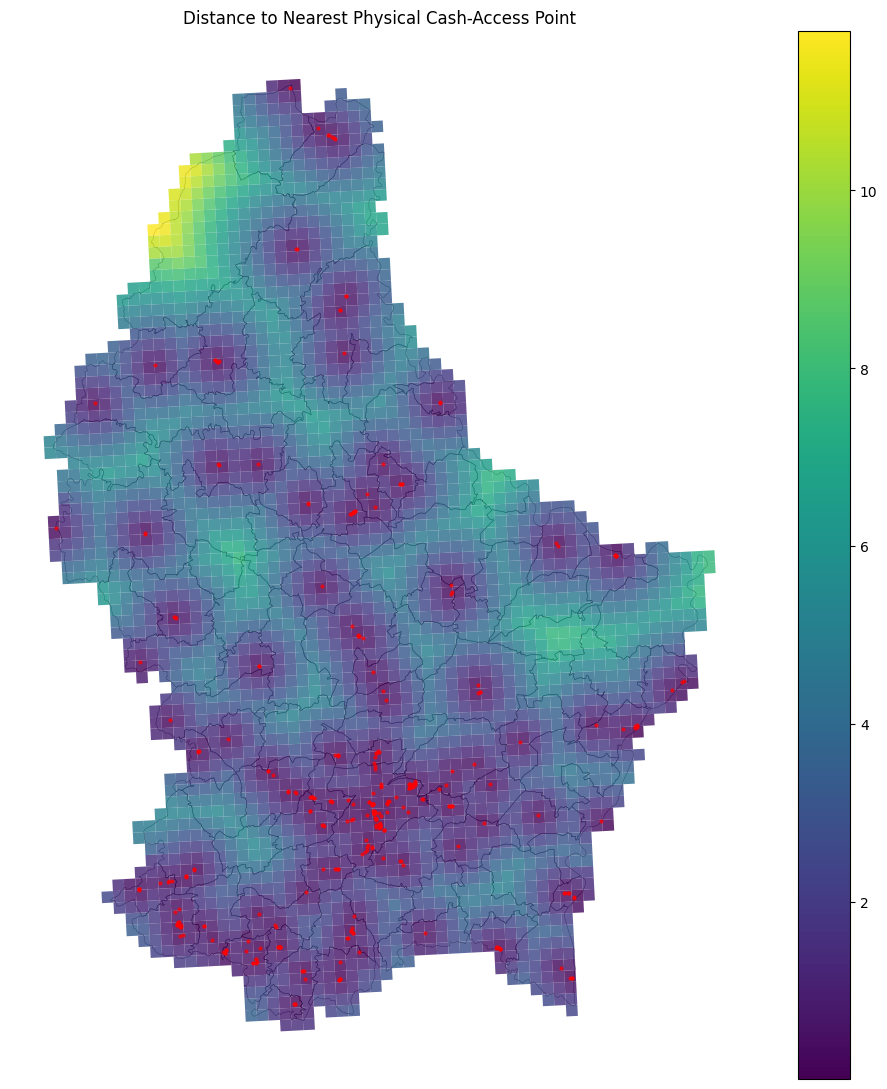

In [ ]:
# ACCESSIBILITY MAP — ALL CASH ACCESS


fig, ax = plt.subplots(figsize=(10, 11))

communes.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.35
)

population.plot(
    ax=ax,
    column="distance_all_km",
    cmap="viridis",
    legend=True,
    alpha=0.82
)

cash.plot(
    ax=ax,
    color="red",
    markersize=4,
    alpha=0.65
)

ax.set_title(
    "Distance to Nearest Physical Cash-Access Point"
)
ax.set_axis_off()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "01_all_cash_accessibility_map.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


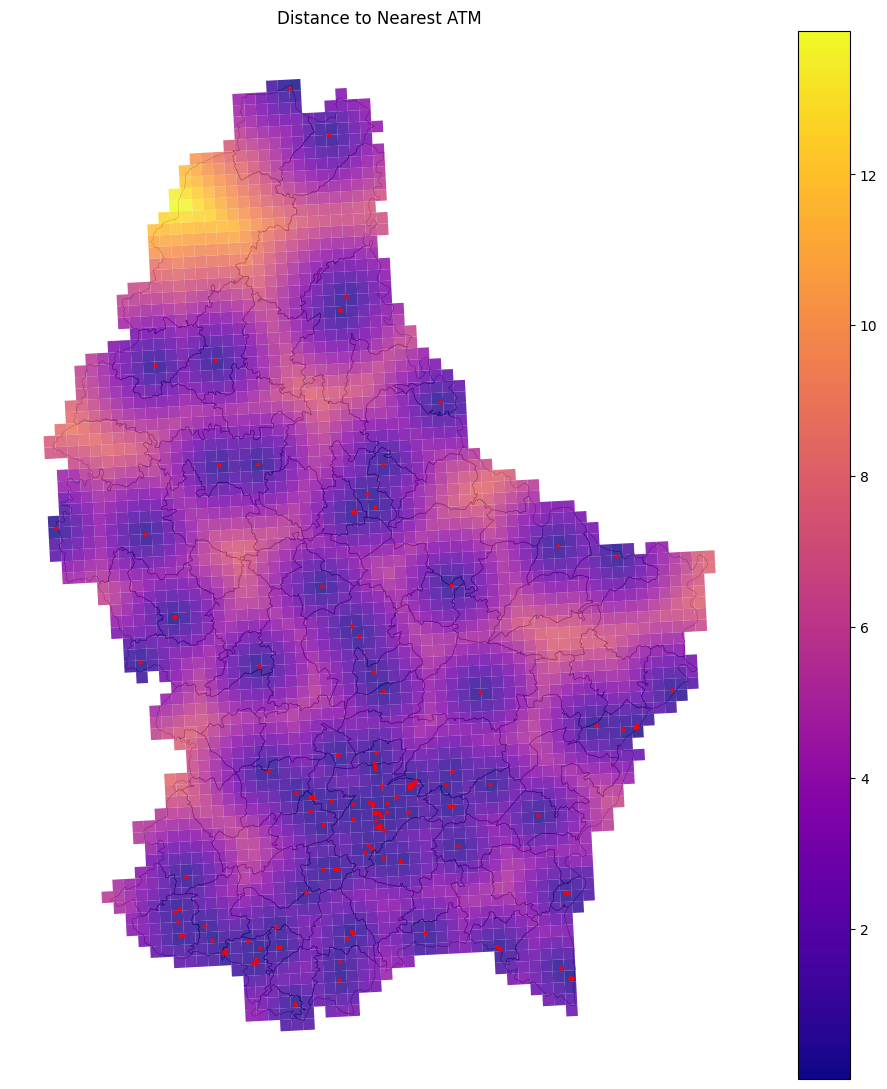

In [ ]:

# ACCESSIBILITY MAP — ATM ONLY
 

fig, ax = plt.subplots(figsize=(10, 11))

communes.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.35
)

population.plot(
    ax=ax,
    column="distance_atm_km",
    cmap="plasma",
    legend=True,
    alpha=0.82
)

atm.plot(
    ax=ax,
    color="red",
    markersize=5,
    alpha=0.75
)

ax.set_title(
    "Distance to Nearest ATM"
)
ax.set_axis_off()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "02_atm_accessibility_map.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# PART II — Accessibility inequality
By calculating:

- quantiles;
- population-weighted threshold coverage;
- concentration of poorly served population;
- an exposure measure for population beyond specified distance thresholds.


In [ ]:
# ACCESSIBILITY DISTRIBUTION


distribution = pd.DataFrame({
    "all_cash_distance_km": population["distance_all_km"],
    "atm_distance_km": population["distance_atm_km"],
    "population": population["population_2021"]
})

display(
    distribution[
        ["all_cash_distance_km", "atm_distance_km"]
    ].describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)


,all_cash_distance_km,atm_distance_km
count,2794.000000,2794.000000
mean,3.058553,3.610994
std,1.897666,2.213067
min,0.006586,0.006586
10%,0.859061,1.054812
25%,1.615965,1.937358
50%,2.796850,3.293256
75%,4.171115,4.849936
90%,5.467817,6.466657
95%,6.392743,7.491052


In [ ]:
# POPULATION WITH HIGH ACCESS BURDEN


burden_rows = []

for access_type, col in [
    ("All physical cash access", "distance_all_km"),
    ("ATM only", "distance_atm_km")
]:
    for threshold in [1, 2, 5, 10]:
        exposed = population.loc[
            population[col] > threshold,
            "population_2021"
        ].sum()

        burden_rows.append({
            "access_type": access_type,
            "threshold_km": threshold,
            "population_above_threshold": exposed,
            "share_pct": 100 * exposed / population["population_2021"].sum()
        })

burden = pd.DataFrame(burden_rows)

display(burden)

burden.to_csv(
    OUTPUT_DIR / "03_high_access_burden.csv",
    index=False
)


,access_type,threshold_km,population_above_threshold,share_pct
0,All physical cash access,1,221923,34.491157
1,All physical cash access,2,135909,21.122906
2,All physical cash access,5,21855,3.396693
3,All physical cash access,10,239,0.037145
4,ATM only,1,301250,46.820117
5,ATM only,2,200249,31.122595
6,ATM only,5,47812,7.430916
7,ATM only,10,1550,0.240900


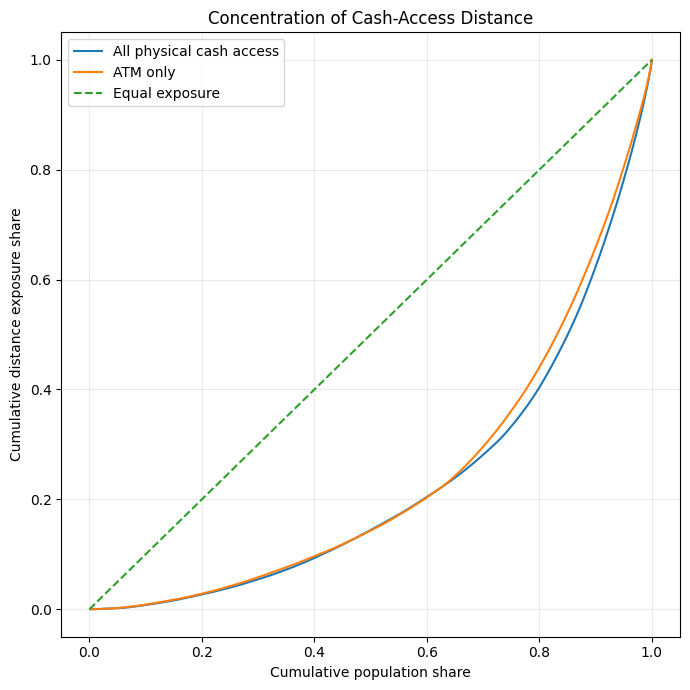

In [ ]:
#  LORENZ-STYLE ACCESSIBILITY CONCENTRATION


def accessibility_concentration(distance_col):
    df = population[
        [distance_col, "population_2021"]
    ].dropna().copy()

    df = df.sort_values(distance_col)

    cumulative_pop = df["population_2021"].cumsum() / df["population_2021"].sum()
    cumulative_exposure = (
        (df[distance_col] * df["population_2021"]).cumsum()
        / (df[distance_col] * df["population_2021"]).sum()
    )

    return cumulative_pop.to_numpy(), cumulative_exposure.to_numpy()

x_all, y_all = accessibility_concentration("distance_all_km")
x_atm, y_atm = accessibility_concentration("distance_atm_km")

fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(x_all, y_all, label="All physical cash access")
ax.plot(x_atm, y_atm, label="ATM only")
ax.plot([0, 1], [0, 1], linestyle="--", label="Equal exposure")

ax.set_xlabel("Cumulative population share")
ax.set_ylabel("Cumulative distance exposure share")
ax.set_title("Concentration of Cash-Access Distance")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "04_accessibility_concentration.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# PART III — Commune-level analysis

Population-grid cells are assigned to a commune using their centroids. This gives one commune-level observation per grid cell and avoids double-counting cells that touch multiple commune polygons.


In [ ]:

#  AREA-WEIGHTED POPULATION ALLOCATION TO COMMUNES by intersecting each population cell with luxembourg communes and allocate its population according to the share of the Luxembourg portion of the cell lying in each commune.

COMMUNE_ID = "COMMUNE"

luxembourg_geometry = communes.geometry.union_all()


pop_alloc = population[
    [
        "GRD_ID",
        "population_2021",
        "geometry"
    ]
].copy()

# Repair geometry before intersection.
pop_alloc["geometry"] = (
    pop_alloc.geometry
    .make_valid()
)

# Clip each grid cell to Luxembourg.
pop_alloc["geometry"] = (
    pop_alloc.geometry
    .intersection(luxembourg_geometry)
)

# Remove  empty geometry.
pop_alloc = pop_alloc[
    ~pop_alloc.geometry.is_empty
    & pop_alloc.geometry.notna()
].copy()

# Area of the Luxembourg portion of each grid cell.
pop_alloc["cell_lux_area_m2"] = (
    pop_alloc.geometry.area
)

pop_alloc = pop_alloc[
    pop_alloc["cell_lux_area_m2"] > 0
].copy()

# Intersect population cells with communes.
pop_commune_intersections = gpd.overlay(
    pop_alloc[
        [
            "GRD_ID",
            "population_2021",
            "cell_lux_area_m2",
            "geometry"
        ]
    ],
    communes[
        [
            COMMUNE_ID,
            "geometry"
        ]
    ],
    how="intersection"
)

# Area of each cell-commune intersection.
pop_commune_intersections["intersection_area_m2"] = (
    pop_commune_intersections.geometry.area
)

# Share of each grid cell falling inside a commune.
pop_commune_intersections["allocation_share"] = (
    pop_commune_intersections["intersection_area_m2"]
    / pop_commune_intersections["cell_lux_area_m2"]
)

# Avoiding any tiny floating-point deviations.
pop_commune_intersections["allocation_share"] = (
    pop_commune_intersections["allocation_share"]
    .clip(lower=0, upper=1)
)

# Allocate population.
pop_commune_intersections["allocated_population"] = (
    pop_commune_intersections["population_2021"]
    * pop_commune_intersections["allocation_share"]
)

# Check conservation of population.
allocated_total = (
    pop_commune_intersections[
        "allocated_population"
    ].sum()
)

source_total = (
    population["population_2021"].sum()
)

print(
    f"Source population: {source_total:,.2f}"
)

print(
    f"Allocated population: {allocated_total:,.2f}"
)

print(
    f"Difference: {allocated_total - source_total:,.6f}"
)

if abs(
    allocated_total - source_total
) > 1:
    raise RuntimeError(
        "Population was not conserved in commune allocation."
    )

print(
    f"Population successfully allocated across "
    f"{pop_commune_intersections[COMMUNE_ID].nunique()} communes."
)

Source population: 643,420.00
Allocated population: 643,420.00
Difference: 0.000000
Population successfully allocated across 100 communes.


In [ ]:
# COMMUNE ACCESSIBILITY METRICS


# Merge the cell-level distance measures into the population/commune and allocated table using GRD_ID.

distance_fields = population[
    [
        "GRD_ID",
        "distance_all_km",
        "distance_atm_km"
    ]
].copy()

pop_commune_intersections = (
    pop_commune_intersections
    .drop(
        columns=[
            "distance_all_km",
            "distance_atm_km"
        ],
        errors="ignore"
    )
    .merge(
        distance_fields,
        on="GRD_ID",
        how="left"
    )
)

# Population-weighted distance contribution.
pop_commune_intersections["weighted_all"] = (
    pop_commune_intersections[
        "distance_all_km"
    ]
    * pop_commune_intersections[
        "allocated_population"
    ]
)

pop_commune_intersections["weighted_atm"] = (
    pop_commune_intersections[
        "distance_atm_km"
    ]
    * pop_commune_intersections[
        "allocated_population"
    ]
)

commune_agg = (
    pop_commune_intersections
    .groupby(COMMUNE_ID)
    .agg(
        population=(
            "allocated_population",
            "sum"
        ),
        weighted_all=(
            "weighted_all",
            "sum"
        ),
        weighted_atm=(
            "weighted_atm",
            "sum"
        ),
        grid_cells=(
            "GRD_ID",
            "nunique"
        )
    )
    .reset_index()
)

commune_agg["all_cash_distance_km"] = (
    commune_agg["weighted_all"]
    / commune_agg["population"].replace(
        0,
        np.nan
    )
)

commune_agg["atm_distance_km"] = (
    commune_agg["weighted_atm"]
    / commune_agg["population"].replace(
        0,
        np.nan
    )
)

commune_metrics = communes[
    [
        COMMUNE_ID,
        "geometry"
    ]
].merge(
    commune_agg,
    on=COMMUNE_ID,
    how="left"
)

commune_metrics["area_km2"] = (
    commune_metrics.geometry.area
    / 1_000_000
)

commune_metrics["population_density"] = (
    commune_metrics["population"]
    / commune_metrics["area_km2"].replace(
        0,
        np.nan
    )
)

commune_metrics["atm_access_gap_km"] = (
    commune_metrics["atm_distance_km"]
    - commune_metrics["all_cash_distance_km"]
)

print(
    "Communes with population:",
    commune_metrics["population"].notna().sum(),
    "/ 100"
)

print(
    "Total commune-allocated population:",
    f"{commune_metrics['population'].sum():,.2f}"
)

display(
    commune_metrics[
        [
            COMMUNE_ID,
            "population",
            "population_density",
            "all_cash_distance_km",
            "atm_distance_km",
            "atm_access_gap_km"
        ]
    ]
    .sort_values(
        "atm_distance_km",
        ascending=False
    )
    .head(20)
)

Communes with population: 100 / 100
Total commune-allocated population: 643,420.00


,COMMUNE,population,population_density,all_cash_distance_km,atm_distance_km,atm_access_gap_km
54,Wincrange,4729.197268,41.551825,6.841620,8.760795,1.919175
63,Boulaide,1440.418380,44.454649,4.675543,7.376929,2.701386
33,Reisdorf,1642.391949,111.198485,6.804833,7.178999,0.374166
72,Bech,1354.864331,57.846059,6.793284,6.941242,0.147958
0,Mertzig,2298.506373,207.159074,3.986083,6.079872,2.093790
78,Clervaux,5734.550150,66.982615,2.584719,5.905842,3.321123
81,Steinfort,5572.678492,457.791006,1.000360,5.753317,4.752957
23,Kiischpelt,1231.755737,36.489319,5.117258,5.410641,0.293383
80,Habscht,4945.089531,151.800750,1.747721,5.339109,3.591387
61,Préizerdaul,1770.620092,112.555303,5.259910,5.321064,0.061154


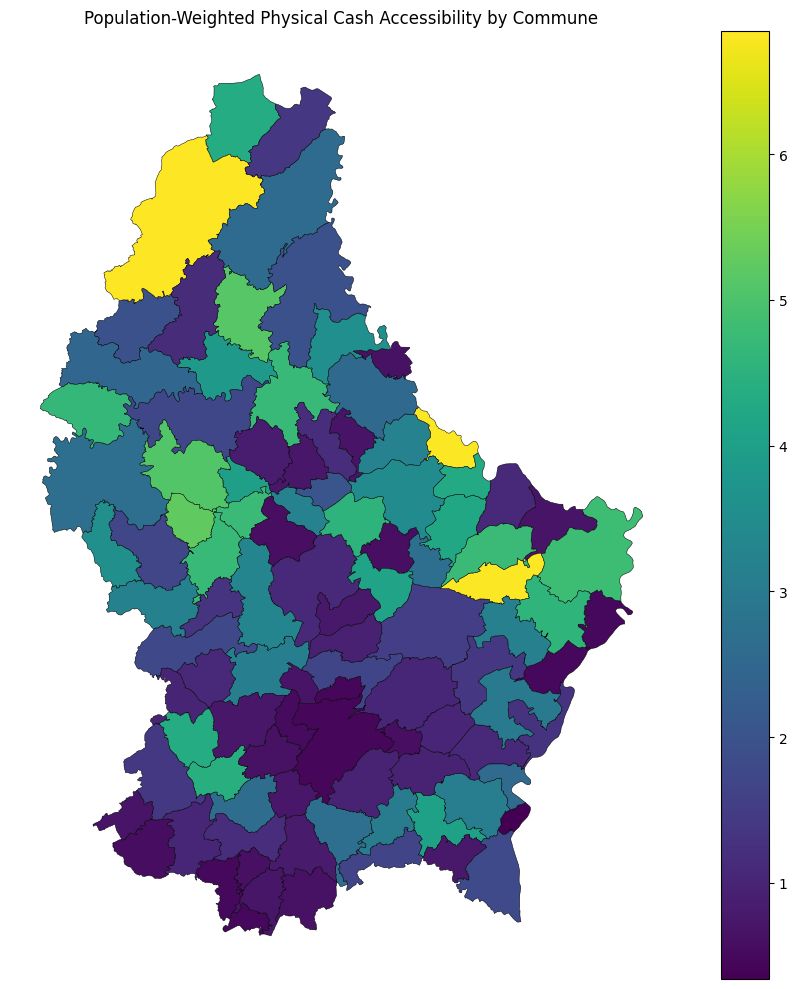

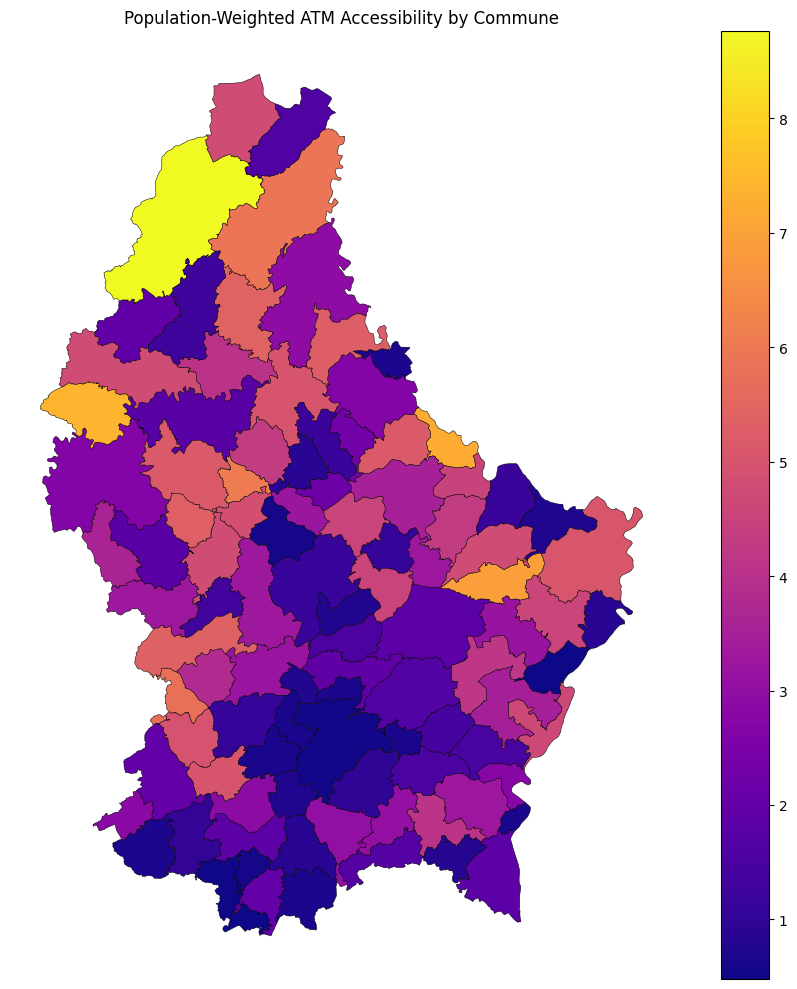

In [ ]:
# COMMUNE ACCESSIBILITY MAPS


fig, ax = plt.subplots(figsize=(10, 10))

commune_metrics.plot(
    ax=ax,
    column="all_cash_distance_km",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.35,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Population-Weighted Physical Cash Accessibility by Commune")
ax.set_axis_off()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "05_commune_all_cash_accessibility.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


fig, ax = plt.subplots(figsize=(10, 10))

commune_metrics.plot(
    ax=ax,
    column="atm_distance_km",
    cmap="plasma",
    legend=True,
    edgecolor="black",
    linewidth=0.35,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Population-Weighted ATM Accessibility by Commune")
ax.set_axis_off()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "06_commune_atm_accessibility.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [ ]:
# WORST-SERVED COMMUNES

worst_communes = (
    commune_metrics[
        [
            "COMMUNE",
            "population",
            "population_density",
            "all_cash_distance_km",
            "atm_distance_km",
            "atm_access_gap_km"
        ]
    ]
    .dropna(subset=["atm_distance_km"])
    .sort_values("atm_distance_km", ascending=False)
)

display(worst_communes.head(20))

worst_communes.to_csv(
    OUTPUT_DIR / "07_commune_accessibility_rankings.csv",
    index=False
)


,COMMUNE,population,population_density,all_cash_distance_km,atm_distance_km,atm_access_gap_km
54,Wincrange,4729.197268,41.551825,6.841620,8.760795,1.919175
63,Boulaide,1440.418380,44.454649,4.675543,7.376929,2.701386
33,Reisdorf,1642.391949,111.198485,6.804833,7.178999,0.374166
72,Bech,1354.864331,57.846059,6.793284,6.941242,0.147958
0,Mertzig,2298.506373,207.159074,3.986083,6.079872,2.093790
78,Clervaux,5734.550150,66.982615,2.584719,5.905842,3.321123
81,Steinfort,5572.678492,457.791006,1.000360,5.753317,4.752957
23,Kiischpelt,1231.755737,36.489319,5.117258,5.410641,0.293383
80,Habscht,4945.089531,151.800750,1.747721,5.339109,3.591387
61,Préizerdaul,1770.620092,112.555303,5.259910,5.321064,0.061154


# PART IV — Cash infrastructure distribution

This section measures how infrastructure is geographically distributed . In this i've distinguished:

- all physical cash-access points;
- Atm;
- bank branches;
- post offices.

While the density calculation is descriptive and uses commune area.


In [ ]:
 #INFRASTRUCTURE COUNTS BY COMMUNE


cash_commune = gpd.sjoin(
    cash,
    communes[["COMMUNE", "geometry"]],
    how="left",
    predicate="within"
)

facility_counts = pd.crosstab(
    cash_commune["COMMUNE"],
    cash_commune["facility_type"]
).reset_index()

commune_metrics = commune_metrics.merge(
    facility_counts,
    on="COMMUNE",
    how="left"
)

for col in ["ATM", "Bank branch", "Post office", "Other"]:
    if col not in commune_metrics.columns:
        commune_metrics[col] = 0
    commune_metrics[col] = commune_metrics[col].fillna(0)

commune_metrics["all_cash_points"] = (
    commune_metrics[["ATM", "Bank branch", "Post office", "Other"]].sum(axis=1)
)

commune_metrics["cash_points_per_1000_people"] = (
    1000 * commune_metrics["all_cash_points"]
    / commune_metrics["population"].replace(0, np.nan)
)

commune_metrics["atms_per_1000_people"] = (
    1000 * commune_metrics["ATM"]
    / commune_metrics["population"].replace(0, np.nan)
)

display(
    commune_metrics[
        [
            "COMMUNE",
            "population",
            "ATM",
            "Bank branch",
            "Post office",
            "all_cash_points",
            "cash_points_per_1000_people"
        ]
    ]
    .sort_values("cash_points_per_1000_people", ascending=False)
    .head(20)
)


,COMMUNE,population,ATM,Bank branch,Post office,all_cash_points,cash_points_per_1000_people
94,Weiswampach,2247.991586,1.0,5.0,0.0,6.0,2.669049
12,Saeul,938.820833,1.0,1.0,0.0,2.0,2.130332
77,Leudelange,2710.920027,4.0,1.0,0.0,5.0,1.844392
26,Sandweiler,3721.166465,3.0,2.0,1.0,6.0,1.612398
79,Grevenmacher,5041.301836,6.0,1.0,1.0,8.0,1.586892
30,Remich,4041.248083,2.0,3.0,1.0,6.0,1.484690
2,Larochette,2102.939183,1.0,1.0,1.0,3.0,1.426575
34,Parc Hosingen,3730.398672,3.0,1.0,1.0,5.0,1.340339
39,Mondorf-les-Bains,5357.000522,2.0,4.0,1.0,7.0,1.306701
3,Kopstal,3618.384395,2.0,1.0,1.0,4.0,1.105466


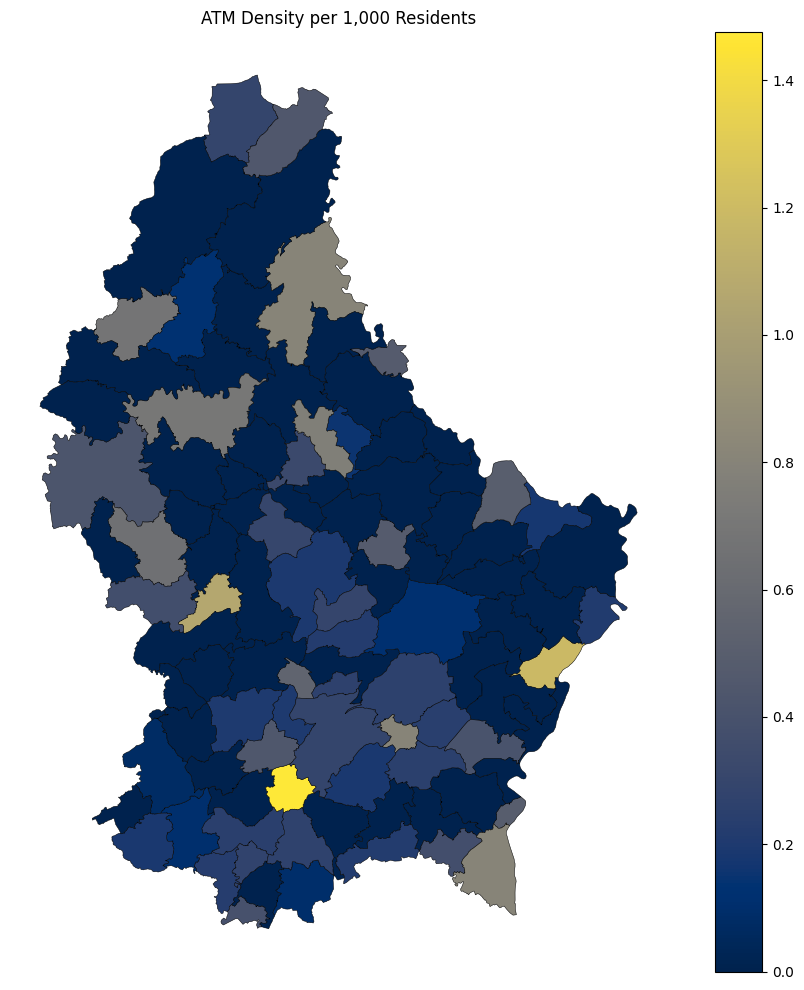

In [ ]:
# INFRASTRUCTURE DENSITY MAP

fig, ax = plt.subplots(figsize=(10, 10))

commune_metrics.plot(
    ax=ax,
    column="atms_per_1000_people",
    cmap="cividis",
    legend=True,
    edgecolor="black",
    linewidth=0.35,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("ATM Density per 1,000 Residents")
ax.set_axis_off()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "08_atm_density_by_commune.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# PART V — ECB ATM infrastructure trend

The ECB time series is **national ATM count**. Hence, it's used for temporal context.


,Year,Total_ATMs,YoY_change_pct
0,2000,325,NaN
1,2001,355,9.230769
2,2002,375,5.633803
3,2003,387,3.200000
4,2004,397,2.583979
5,2005,405,2.015113
6,2006,407,0.493827
7,2007,416,2.211302
8,2008,430,3.365385
9,2009,438,1.860465


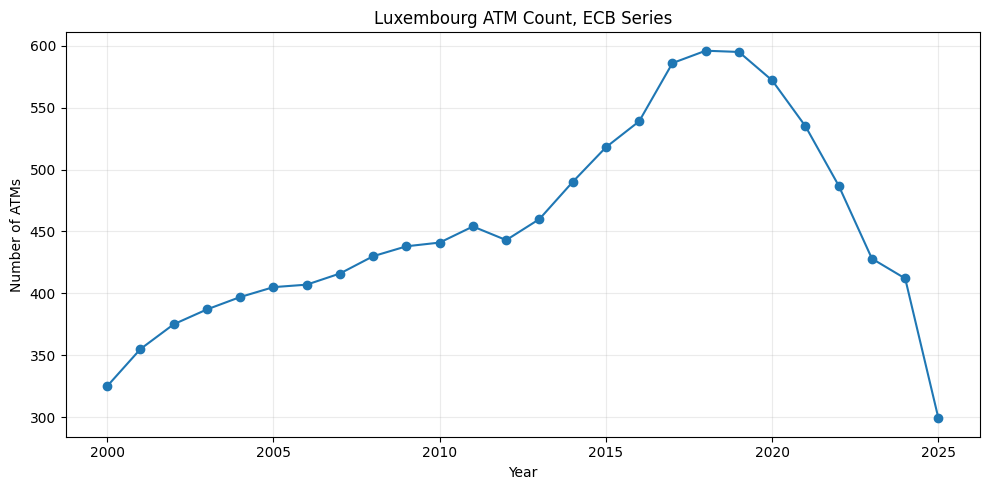

In [ ]:
# ECB ATM TIME SERIES
ecb = ecb_atm.copy()

ecb["Year"] = pd.to_numeric(
    ecb["Year"],
    errors="coerce"
)

ecb["Total_ATMs"] = pd.to_numeric(
    ecb["Total_ATMs"],
    errors="coerce"
)

ecb = (
    ecb.dropna(subset=["Year", "Total_ATMs"])
    .sort_values("Year")
    .reset_index(drop=True)
)

ecb["YoY_change_pct"] = (
    ecb["Total_ATMs"].pct_change() * 100
)

display(ecb)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    ecb["Year"],
    ecb["Total_ATMs"],
    marker="o"
)

ax.set_title("Luxembourg ATM Count, ECB Series")
ax.set_xlabel("Year")
ax.set_ylabel("Number of ATMs")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "09_ecb_atm_time_series.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [ ]:

#ATM TREND SUMMARY


first = ecb.loc[
    ecb["Year"].idxmin()
]

last = ecb.loc[
    ecb["Year"].idxmax()
]

peak = ecb.loc[
    ecb["Total_ATMs"].idxmax()
]

endpoint_change = (
    last["Total_ATMs"]
    - first["Total_ATMs"]
)

endpoint_pct = (
    100 * endpoint_change
    / first["Total_ATMs"]
)

peak_to_latest_change = (
    last["Total_ATMs"]
    - peak["Total_ATMs"]
)

peak_to_latest_pct = (
    100 * peak_to_latest_change
    / peak["Total_ATMs"]
)

print(
    f"ATM count: {first['Total_ATMs']:.0f} "
    f"in {first['Year']:.0f} → "
    f"{last['Total_ATMs']:.0f} "
    f"in {last['Year']:.0f}"
)

print(
    f"2000–2025 endpoint change: "
    f"{endpoint_change:.0f} "
    f"({endpoint_pct:.2f}%)"
)

print(
    f"Peak: {peak['Total_ATMs']:.0f} "
    f"in {peak['Year']:.0f}"
)

print(
    f"Peak-to-2025 change: "
    f"{peak_to_latest_change:.0f} "
    f"({peak_to_latest_pct:.2f}%)"
)


ATM count: 325 in 2000 → 299 in 2025
2000–2025 endpoint change: -26 (-8.00%)
Peak: 596 in 2018
Peak-to-2025 change: -297 (-49.83%)


# PART VI — Spatial statistics

Using PySAL stack for:

- **Global Moran's I** for overall spatial clustering
- **Local Moran's I / LISA** for localized clusters

The spatial unit is the **commune**, using population-weighted accessibility as the outcome.


In [ ]:
# 
# 22. IMPORT SPATIAL STATISTICS
# 

try:
    from libpysal.weights import Queen, KNN
    from esda.moran import Moran, Moran_Local
    from spreg import OLS as SpregOLS, ML_Lag, ML_Error
    SPATIAL_PACKAGES_AVAILABLE = True
    print("✓ PySAL spatial-analysis stack available.")
except Exception as exc:
    SPATIAL_PACKAGES_AVAILABLE = False
    print("Spatial packages unavailable:", exc)
    print("Install with: pip install libpysal esda spreg")


✓ PySAL spatial-analysis stack available.


In [ ]:
 #  MORAN'S I + LISA


if SPATIAL_PACKAGES_AVAILABLE:

    spatial_df = commune_metrics.dropna(
        subset=["atm_distance_km"]
    ).copy()

    y = spatial_df["atm_distance_km"].to_numpy()

    # Queen contiguity; use KNN if the Queen graph is disconnected.
    w = Queen.from_dataframe(
        spatial_df,
        use_index=False
    )

    if w.n_components > 1:
        print(
            f"Queen weights have {w.n_components} connected components. "
            "Using 5-nearest-neighbour weights."
        )
        w = KNN.from_dataframe(
            spatial_df,
            k=min(5, len(spatial_df) - 1),
            use_index=False
        )

    w.transform = "r"

    moran = Moran(y, w)

    print(f"Moran's I: {moran.I:.5f}")
    print(f"Expected I: {moran.EI:.5f}")
    print(f"Permutation p-value: {moran.p_sim:.5f}")

    lisa = Moran_Local(y, w)

    spatial_df["lisa_I"] = lisa.Is
    spatial_df["lisa_p"] = lisa.p_sim
    spatial_df["lisa_q"] = lisa.q

    labels = {
        1: "High-High",
        2: "Low-Low",
        3: "Low-High",
        4: "High-Low"
    }

    spatial_df["lisa_cluster"] = [
        labels.get(q, "Unclassified")
        if p < 0.05
        else "Not significant"
        for q, p in zip(lisa.q, lisa.p_sim)
    ]

    print("\nLISA clusters:")
    print(spatial_df["lisa_cluster"].value_counts())

else:
    print("Skipped spatial statistics because PySAL is unavailable.")


Moran's I: 0.17492
Expected I: -0.01010
Permutation p-value: 0.00600

LISA clusters:
lisa_cluster
Not significant    81
Low-High           12
Low-Low             4
High-High           2
High-Low            1
Name: count, dtype: int64


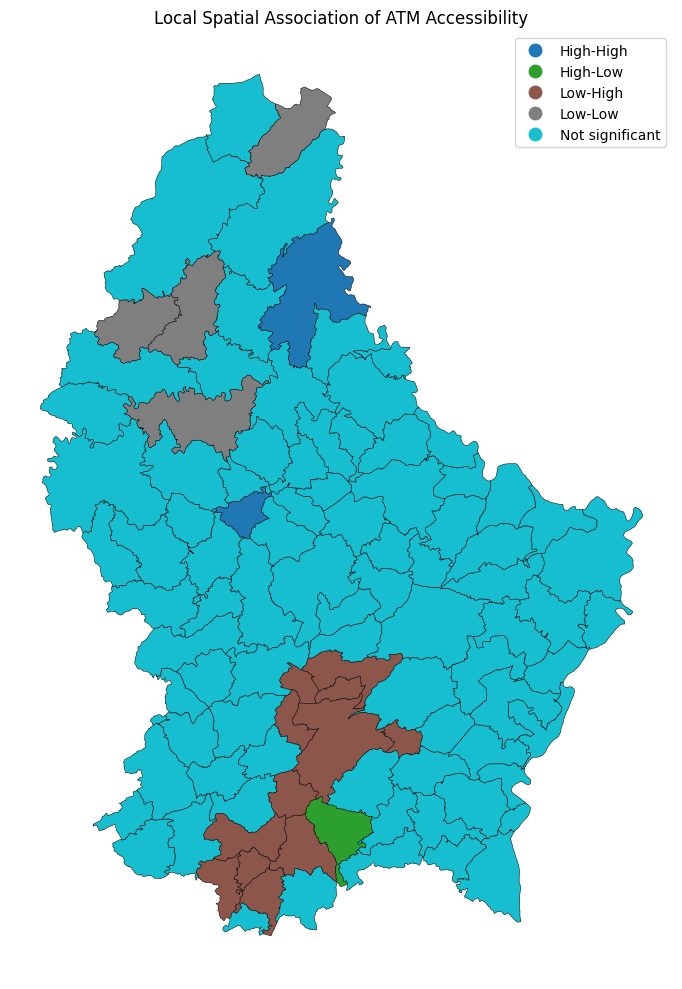

In [ ]:
# LISA MAP

if SPATIAL_PACKAGES_AVAILABLE:

    fig, ax = plt.subplots(figsize=(10, 10))

    spatial_df.plot(
        ax=ax,
        column="lisa_cluster",
        categorical=True,
        legend=True,
        edgecolor="black",
        linewidth=0.35
    )

    ax.set_title(
        "Local Spatial Association of ATM Accessibility"
    )
    ax.set_axis_off()
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "10_atm_accessibility_lisa.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()


# PART VII — Exploratory spatial econometrics

I estimated an exploratory cross-sectional relationship between:**ATM accessibility distance** and **population density**.

This is **not causal**. It is a demonstration of spatial econometric reasoning with further plans to expanded with income, age, employment, deprivation and other official STATEC variables.


In [ ]:
# BUILD MODEL DATASET

model_df = commune_metrics.dropna(
    subset=[
        "atm_distance_km",
        "population_density"
    ]
).copy()

model_df["log_population_density"] = np.log1p(
    model_df["population_density"]
)

print("Model observations:", len(model_df))

display(
    model_df[
        [
            "COMMUNE",
            "atm_distance_km",
            "population_density",
            "log_population_density"
        ]
    ].describe()
)


Model observations: 100


,atm_distance_km,population_density,log_population_density
count,100.000000,100.000000,100.000000
mean,2.843293,309.388736,5.182756
std,1.935855,430.310631,0.984548
min,0.478953,36.489319,3.624056
25%,1.069787,82.077488,4.419570
50%,2.691611,155.019632,5.049853
75%,4.540370,310.058028,5.739940
max,8.760795,2453.381832,7.805630


In [ ]:
# OLS + HETEROSKEDASTICITY-ROBUST INFERENCE

import statsmodels.api as sm

X = sm.add_constant(
    model_df[["log_population_density"]]
)

y = model_df["atm_distance_km"]

ols_sm = sm.OLS(
    y,
    X
).fit(
    cov_type="HC3"
)

print(ols_sm.summary())


                            OLS Regression Results                            
Dep. Variable:        atm_distance_km   R-squared:                       0.384
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     65.42
Date:                Tue, 25 Aug 2026   Prob (F-statistic):           1.64e-12
Time:                        12:31:11   Log-Likelihood:                -183.21
No. Observations:                 100   AIC:                             370.4
Df Residuals:                      98   BIC:                             375.6
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      9

In [ ]:
# SPATIAL LAG / ERROR MODELS


if SPATIAL_PACKAGES_AVAILABLE:

    w_model = Queen.from_dataframe(
        model_df,
        use_index=False
    )

    if w_model.n_components > 1:
        w_model = KNN.from_dataframe(
            model_df,
            k=min(5, len(model_df) - 1),
            use_index=False
        )

    w_model.transform = "r"

    y_sp = model_df[
        "atm_distance_km"
    ].to_numpy().reshape(-1, 1)

    X_sp = model_df[
        ["log_population_density"]
    ].to_numpy()

    sp_ols = SpregOLS(
        y_sp,
        X_sp,
        w=w_model,
        name_y="atm_distance_km",
        name_x=["log_population_density"]
    )

    print("=== Spatial OLS ===")
    print(sp_ols.summary)

    sar = ML_Lag(
        y_sp,
        X_sp,
        w=w_model,
        name_y="atm_distance_km",
        name_x=["log_population_density"]
    )

    print("=== Spatial Lag Model ===")
    print(sar.summary)

    sem = ML_Error(
        y_sp,
        X_sp,
        w=w_model,
        name_y="atm_distance_km",
        name_x=["log_population_density"]
    )

    print("=== Spatial Error Model ===")
    print(sem.summary)

else:
    print("Spatial lag/error models skipped.")


=== Spatial OLS ===
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :atm_distance_km                Number of Observations:         100
Mean dependent var  :      2.8433                Number of Variables   :           2
S.D. dependent var  :      1.9359                Degrees of Freedom    :          98
R-squared           :      0.3842
Adjusted R-squared  :      0.3779
Sum squared residual:     228.469                F-statistic           :     61.1402
Sigma-square        :       2.331                Prob(F-statistic)     :   6.153e-12
S.E. of regression  :       1.527                Log likelihood        :    -183.205
Sigma-square ML     :       2.285                Akaike info criterion :     370.411
S.E of regression ML:      1.5115                Schwarz criterion     :     375

# PART VIII — Road-network accessibility

The downloaded graph is a **drive network**.So the following analysis measures **route distance over the road network**, not walking distance.

The multi-source shortest-path calculation treats each cash-access point as a source and finds the shortest route from each population centroid to its nearest source.


In [ ]:
# ROBUST NETWORK ACCESSIBILITY — DIRECT SHORTEST PATHS


def prepare_network_accessibility(
    graph,
    population_points,
    facility_points
):
    """
    Road-network distance from each population representative point
    to the nearest facility.

    Uses:
      point -> nearest road node
      shortest road path
      nearest facility node -> facility point

    Returns kilometres.
    """

    # Undirected graph for physical accessibility.
    H = graph.to_undirected()

    # Ensuring numeric edge lengths.
    for u, v, data in H.edges(data=True):
        try:
            data["length"] = float(data.get("length", 0.0))
        except Exception:
            data["length"] = 0.0

    # Snapping population points.
    pop_nodes = ox.distance.nearest_nodes(
        H,
        X=population_points.geometry.x.to_numpy(),
        Y=population_points.geometry.y.to_numpy()
    )

    # Snapping facility points.
    facility_nodes = ox.distance.nearest_nodes(
        H,
        X=facility_points.geometry.x.to_numpy(),
        Y=facility_points.geometry.y.to_numpy()
    )

    # Point-to-node connector distance.
    pop_connector = np.array([
        math.hypot(
            population_points.geometry.iloc[i].x
            - H.nodes[node]["x"],
            population_points.geometry.iloc[i].y
            - H.nodes[node]["y"]
        )
        for i, node in enumerate(pop_nodes)
    ])

    facility_connector = np.array([
        math.hypot(
            facility_points.geometry.iloc[i].x
            - H.nodes[node]["x"],
            facility_points.geometry.iloc[i].y
            - H.nodes[node]["y"]
        )
        for i, node in enumerate(facility_nodes)
    ])

    # for repeated facility nodes, retaining the minimum connector.
    facility_node_cost = {}

    for node, cost in zip(
        facility_nodes,
        facility_connector
    ):
        facility_node_cost[node] = min(
            cost,
            facility_node_cost.get(node, np.inf)
        )

    facility_nodes_unique = list(
        facility_node_cost.keys()
    )

    # For every population node, compute shortest road distance to the closest facility node.

    result = np.full(
        len(pop_nodes),
        np.nan,
        dtype=float
    )

    for i, pop_node in enumerate(pop_nodes):

        try:
            lengths = nx.single_source_dijkstra_path_length(
                H,
                pop_node,
                weight="length"
            )
        except Exception:
            continue

        best = np.inf

        for facility_node in facility_nodes_unique:

            if facility_node in lengths:

                candidate = (
                    lengths[facility_node]
                    + facility_node_cost[facility_node]
                )

                if candidate < best:
                    best = candidate

        if np.isfinite(best):
            result[i] = (
                best + pop_connector[i]
            )

    return (
        result / 1000.0,
        pop_nodes,
        facility_nodes
    )

In [ ]:
# NETWORK COMPONENT DIAGNOSTIC-: Convert to an undirected graph to identify physical road connectivity.
G_undirected = nx.Graph(G)

components = list(
    nx.connected_components(G_undirected)
)

components = sorted(
    components,
    key=len,
    reverse=True
)

print(
    f"Number of connected components: {len(components)}"
)

print(
    "Largest component nodes:",
    len(components[0])
)

print(
    "Second-largest component nodes:",
    len(components[1])
    if len(components) > 1
    else 0
)

 
# TO CHECK POPULATION NETWORK COMPONENTS


pop_component_nodes = ox.distance.nearest_nodes(
    G_undirected,
    X=pop_centroids.geometry.x.to_numpy(),
    Y=pop_centroids.geometry.y.to_numpy()
)

largest_component = components[0]

pop_centroids["network_node"] = pop_component_nodes

pop_centroids["in_largest_component"] = (
    pop_centroids["network_node"]
    .isin(largest_component)
)

print(
    "Population analysis points in largest component:",
    pop_centroids["in_largest_component"].sum(),
    "/",
    len(pop_centroids)
)

display(
    population[
        ["GRD_ID", "population_2021"]
    ]
    .loc[
        ~population["GRD_ID"].isin(
            pop_centroids.loc[
                pop_centroids["in_largest_component"],
                "GRD_ID"
            ]
        )
    ]
)

cash_network_nodes = ox.distance.nearest_nodes(
    G_undirected,
    X=cash.geometry.x.to_numpy(),
    Y=cash.geometry.y.to_numpy()
)

atm_network_nodes = ox.distance.nearest_nodes(
    G_undirected,
    X=atm.geometry.x.to_numpy(),
    Y=atm.geometry.y.to_numpy()
)

print(
    "Cash facilities in largest component:",
    sum(
        node in largest_component
        for node in cash_network_nodes
    ),
    "/",
    len(cash_network_nodes)
)

print(
    "ATMs in largest component:",
    sum(
        node in largest_component
        for node in atm_network_nodes
    ),
    "/",
    len(atm_network_nodes)
)

Number of connected components: 1
Largest component nodes: 23529
Second-largest component nodes: 0
Population analysis points in largest component: 2794 / 2794


,GRD_ID,population_2021
1088,CRS3035RES1000mN2963000E4023000,0


Cash facilities in largest component: 332 / 332
ATMs in largest component: 139 / 139


In [ ]:
# CALCULATING ROAD-NETWORK ACCESSIBILITY

# All physical cash access
(
    network_all_distances,
    population_network_nodes,
    cash_network_nodes
) = prepare_network_accessibility(
    G,
    pop_centroids,
    cash
)

# ATM only
(
    network_atm_distances,
    _,
    atm_network_nodes
) = prepare_network_accessibility(
    G,
    pop_centroids,
    atm
)

# 
# Storing results by GRD_IDbecause pop_centroids has 2,794 usable cells while population has all 2,795 official cells.


network_results = pd.DataFrame({
    "GRD_ID": pop_centroids["GRD_ID"].to_numpy(),

    "network_all_cash_km":
        network_all_distances,

    "network_atm_km":
        network_atm_distances
})


population = population.drop(
    columns=[
        "network_all_cash_km",
        "network_atm_km"
    ],
    errors="ignore"
)

# Merge results back to all 2,795 population cells.
population = population.merge(
    network_results,
    on="GRD_ID",
    how="left",
    validate="one_to_one"
)

print(
    "Population cells:",
    len(population)
)

print(
    "Population cells with all-cash network distance:",
    population["network_all_cash_km"].notna().sum()
)

print(
    "Population cells with ATM network distance:",
    population["network_atm_km"].notna().sum()
)

print(
    "Population cells without all-cash network distance:",
    population["network_all_cash_km"].isna().sum()
)

print(
    "Population cells without ATM network distance:",
    population["network_atm_km"].isna().sum()
)

print(
    "Population represented by missing all-cash network distance:",
    population.loc[
        population["network_all_cash_km"].isna(),
        "population_2021"
    ].sum()
)

# Population-weighted network metrics
weighted_network_all = weighted_mean(
    population["network_all_cash_km"],
    population["population_2021"]
)

weighted_network_atm = weighted_mean(
    population["network_atm_km"],
    population["population_2021"]
)

print(
    f"Population-weighted drive-network distance "
    f"to physical cash access: "
    f"{weighted_network_all:.3f} km"
)

print(
    f"Population-weighted drive-network distance "
    f"to ATM: "
    f"{weighted_network_atm:.3f} km"
)

Population cells: 2795
Population cells with all-cash network distance: 2794
Population cells with ATM network distance: 2794
Population cells without all-cash network distance: 1
Population cells without ATM network distance: 1
Population represented by missing all-cash network distance: 0
Population-weighted drive-network distance to physical cash access: 1.921 km
Population-weighted drive-network distance to ATM: 2.546 km


In [ ]:
# STRAIGHT-LINE VS ROAD-NETWORK DIAGNOSTICS

network_comparison = population[
    [
        "GRD_ID",
        "distance_all_km",
        "network_all_cash_km",
        "distance_atm_km",
        "network_atm_km",
        "population_2021"
    ]
].copy()

network_comparison[
    "all_cash_network_ratio"
] = (
    network_comparison["network_all_cash_km"]
    / network_comparison["distance_all_km"]
)

network_comparison[
    "atm_network_ratio"
] = (
    network_comparison["network_atm_km"]
    / network_comparison["distance_atm_km"]
)

print(
    "Network accessibility diagnostics"
)

display(
    network_comparison.describe()
)

for name, straight_col, network_col in [
    (
        "All physical cash access",
        "distance_all_km",
        "network_all_cash_km"
    ),
    (
        "ATM",
        "distance_atm_km",
        "network_atm_km"
    )
]:

    valid = network_comparison[
        [straight_col, network_col]
    ].dropna()

    ratio = (
        valid[network_col]
        / valid[straight_col]
    )

    print(f"\n{name}")
    print(
        f"Valid observations: {len(valid):,}"
    )
    print(
        f"Mean network/straight-line ratio: "
        f"{ratio.mean():.3f}"
    )
    print(
        f"Median network/straight-line ratio: "
        f"{ratio.median():.3f}"
    )
    print(
        f"Share network >= straight-line: "
        f"{100 * (network_comparison.loc[valid.index, network_col] >= network_comparison.loc[valid.index, straight_col]).mean():.2f}%"
    )
    

Network accessibility diagnostics


,distance_all_km,network_all_cash_km,distance_atm_km,network_atm_km,population_2021,all_cash_network_ratio,atm_network_ratio
count,2794.000000,2794.000000,2794.000000,2794.000000,2795.000000,2794.000000,2794.000000
mean,3.058553,4.735554,3.610994,5.551472,230.203936,1.637412,1.617174
std,1.897666,2.793168,2.213067,3.272256,749.985928,0.618727,0.560707
min,0.006586,0.023006,0.006586,0.023006,0.000000,1.000917,1.000917
25%,1.615965,2.455386,1.937358,3.062840,0.000000,1.284844,1.293314
50%,2.796850,4.473869,3.293256,5.153388,6.000000,1.478161,1.478320
75%,4.171115,6.559810,4.849936,7.435035,126.000000,1.797344,1.776468
max,11.787036,14.942097,13.891816,18.309497,14663.000000,11.543937,10.642525



All physical cash access
Valid observations: 2,794
Mean network/straight-line ratio: 1.637
Median network/straight-line ratio: 1.478
Share network >= straight-line: 100.00%

ATM
Valid observations: 2,794
Mean network/straight-line ratio: 1.617
Median network/straight-line ratio: 1.478
Share network >= straight-line: 100.00%


# PART IX — Infrastructure resilience

A key financial-infrastructure question is not just **where the current network is**, but: > **What happens to population access if an ATM or cash-access point disappears?**

For this simulated single-point closures.

### Interpretation

For each candidate closure:

\[
\Delta d_i = {d_i after} - {d_i before}
\]

where \(d_i\) is distance for population grid cell \(i\).

I then calculated:

- population-weighted additional distance;
- population experiencing at least +1 km;
- population experiencing at least +2 km.

These are only **scenario impacts**, not forecasts or causal estimates.


In [ ]:
# FAST PROJECTED-DISTANCE ATM CLOSURE ENGINE

from scipy.spatial import cKDTree


def nearest_two_projected(
    population_points,
    facility_points
):
    """
    Find the nearest and second-nearest facilities using
    projected LUREF coordinates.

    Returns:
        nearest distance (km)
        second-nearest distance (km)
        nearest facility index
        second-nearest facility index
    """

    pop_xy = np.column_stack([
        population_points.geometry.x.to_numpy(),
        population_points.geometry.y.to_numpy()
    ])

    facility_xy = np.column_stack([
        facility_points.geometry.x.to_numpy(),
        facility_points.geometry.y.to_numpy()
    ])

    if len(facility_xy) < 2:
        raise ValueError(
            "At least two ATM facilities are required."
        )

    tree = cKDTree(
        facility_xy
    )

    distances_m, positions = tree.query(
        pop_xy,
        k=2
    )

    facility_indices = np.asarray(
        facility_points.index
    )

    nearest_index = facility_indices[
        positions[:, 0]
    ]

    second_nearest_index = facility_indices[
        positions[:, 1]
    ]

    return (
        distances_m[:, 0] / 1000,
        distances_m[:, 1] / 1000,
        nearest_index,
        second_nearest_index
    )



# Calculate nearest and second-nearest ATM for the 2,794 usable analysis cells


(
    atm_d1_km,
    atm_d2_km,
    atm_1_idx,
    atm_2_idx
) = nearest_two_projected(
    pop_centroids,
    atm
)



# Storing results by GRD_ID


closure_metrics = pd.DataFrame({
    "GRD_ID": pop_centroids["GRD_ID"].to_numpy(),

    "closure_baseline_atm_km":
        atm_d1_km,

    "closure_second_atm_km":
        atm_d2_km,

    "closure_nearest_atm_index":
        atm_1_idx,

    "closure_second_atm_index":
        atm_2_idx
})



# Merged back onto the fULL 2,795-cell population dataset


population = population.drop(
    columns=[
        "closure_baseline_atm_km",
        "closure_second_atm_km",
        "closure_nearest_atm_index",
        "closure_second_atm_index"
    ],
    errors="ignore"
)

population = population.merge(
    closure_metrics,
    on="GRD_ID",
    how="left",
    validate="one_to_one"
)



# Validation


print(
    "Population cells:",
    len(population)
)

print(
    "Cells with closure baseline:",
    population[
        "closure_baseline_atm_km"
    ].notna().sum()
)

print(
    "Cells without closure baseline:",
    population[
        "closure_baseline_atm_km"
    ].isna().sum()
)



# Comparing closure baseline with main ATM accessibility


closure_baseline_weighted = weighted_mean(
    population[
        "closure_baseline_atm_km"
    ],
    population[
        "population_2021"
    ]
)

main_baseline_weighted = weighted_mean(
    population[
        "distance_atm_km"
    ],
    population[
        "population_2021"
    ]
)

print(
    f"\nClosure baseline weighted ATM distance: "
    f"{closure_baseline_weighted:.6f} km"
)

print(
    f"Main-analysis weighted ATM distance: "
    f"{main_baseline_weighted:.6f} km"
)

print(
    f"Difference: "
    f"{closure_baseline_weighted - main_baseline_weighted:.9f} km"
)

Population cells: 2795
Cells with closure baseline: 2794
Cells without closure baseline: 1

Closure baseline weighted ATM distance: 1.742153 km
Main-analysis weighted ATM distance: 1.742153 km
Difference: 0.000000000 km


In [ ]:

# SINGLE ATM CLOSURE IMPACTS

def rank_atm_closures(
    population_gdf,
    atm_gdf
):

    # Only cells with valid ATM distances can participate in the closure simulation.
    valid = (
        population_gdf["closure_baseline_atm_km"].notna()
        & population_gdf["closure_second_atm_km"].notna()
        & population_gdf["closure_nearest_atm_index"].notna()
        & population_gdf["population_2021"].notna()
    )

    analysis = population_gdf.loc[
        valid
    ].copy()

    weights = (
        analysis["population_2021"]
        .to_numpy(dtype=float)
    )

    baseline = (
        analysis["closure_baseline_atm_km"]
        .to_numpy(dtype=float)
    )

    second_best = (
        analysis["closure_second_atm_km"]
        .to_numpy(dtype=float)
    )

    nearest_idx = (
        analysis["closure_nearest_atm_index"]
        .to_numpy()
    )

    total_pop = weights.sum()

    before_weighted = (
        baseline * weights
    ).sum() / total_pop

    results = []

    for atm_idx in atm_gdf.index:

        # Only population cells whose nearest ATM is the closed facility experience an accessibility change.
        after = np.where(
            nearest_idx == atm_idx,
            second_best,
            baseline
        )

        extra = np.maximum(
            after - baseline,
            0
        )

        after_weighted = (
            after * weights
        ).sum() / total_pop

        results.append({
            "facility_index": atm_idx,

            "weighted_distance_before_km":
                before_weighted,

            "weighted_distance_after_km":
                after_weighted,

            "weighted_distance_increase_km":
                after_weighted - before_weighted,

            "population_extra_distance_ge_1km":
                weights[extra >= 1].sum(),

            "population_extra_distance_ge_2km":
                weights[extra >= 2].sum(),

            "population_extra_distance_ge_5km":
                weights[extra >= 5].sum()
        })

    return (
        pd.DataFrame(results)
        .sort_values(
            "weighted_distance_increase_km",
            ascending=False
        )
        .reset_index(drop=True)
    )


atm_closure_results = rank_atm_closures(
    population,
    atm
)

display(
    atm_closure_results.head(20)
)

atm_closure_results.to_csv(
    OUTPUT_DIR /
    "11_atm_closure_impacts.csv",
    index=False
)

,facility_index,weighted_distance_before_km,weighted_distance_after_km,weighted_distance_increase_km,population_extra_distance_ge_1km,population_extra_distance_ge_2km,population_extra_distance_ge_5km
0,205,1.742153,1.808921,0.066767,8611.0,7855.0,3645.0
1,284,1.742153,1.805712,0.063559,16556.0,11128.0,0.0
2,282,1.742153,1.804239,0.062086,10414.0,8607.0,2548.0
3,161,1.742153,1.800466,0.058312,14442.0,11798.0,0.0
4,271,1.742153,1.798103,0.055949,7811.0,7719.0,1024.0
5,225,1.742153,1.796870,0.054716,6614.0,6243.0,3780.0
6,196,1.742153,1.781389,0.039235,6153.0,5477.0,2183.0
7,169,1.742153,1.777349,0.035196,6094.0,5519.0,0.0
8,154,1.742153,1.775342,0.033189,6773.0,5220.0,140.0
9,220,1.742153,1.774209,0.032055,7244.0,4637.0,0.0


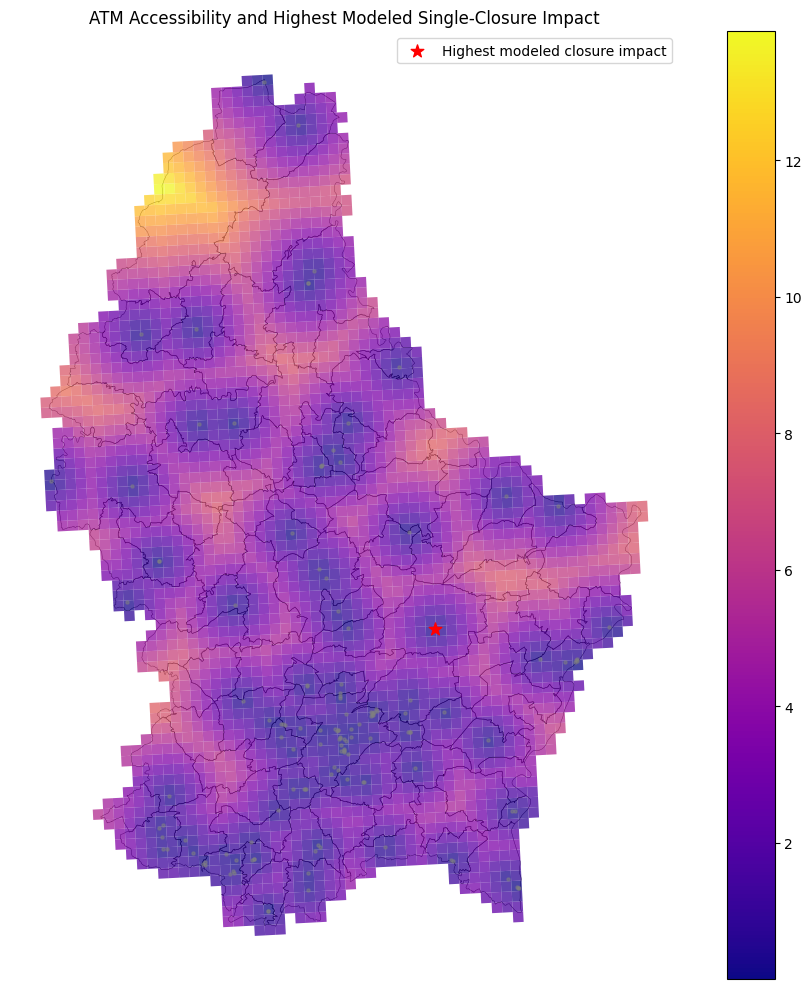

In [ ]:

#  MAPPING THE MOST VULNERABLE ATM


if len(atm_closure_results) > 0:

    worst_atm_idx = (
        atm_closure_results
        .iloc[0]["facility_index"]
    )

    worst_atm = atm.loc[
        [worst_atm_idx]
    ]

    fig, ax = plt.subplots(
        figsize=(10, 10)
    )

    communes.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        linewidth=0.35
    )

    population.plot(
        ax=ax,
        column="distance_atm_km",
        cmap="plasma",
        legend=True,
        alpha=0.75
    )

    atm.plot(
        ax=ax,
        color="grey",
        markersize=5,
        alpha=0.5
    )

    worst_atm.plot(
        ax=ax,
        color="red",
        markersize=90,
        marker="*",
        label="Highest modeled closure impact"
    )

    ax.set_title(
        "ATM Accessibility and Highest Modeled Single-Closure Impact"
    )

    ax.set_axis_off()
    ax.legend()

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR /
        "12_worst_atm_closure_map.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# PART X — Research-ready outputs

The following cells will save:

- population-level accessibility;
- commune-level metrics;
- spatial statistics;
- closure-scenario results;
- summary indicators.




In [ ]:
 
#POPULATION-LEVEL EXPORT


population_export = population.copy()

population_export.to_file(
    OUTPUT_DIR / "cashaccess_population_metrics.gpkg",
    layer="population_metrics",
    driver="GPKG"
)

print("✓ population metrics exported")


✓ population metrics exported


In [ ]:
 # COMMUNE-LEVEL EXPORT


commune_metrics.to_file(
    OUTPUT_DIR / "cashaccess_commune_metrics.gpkg",
    layer="commune_metrics",
    driver="GPKG"
)

print("✓ commune metrics exported")


✓ commune metrics exported


In [ ]:
 
# ATM CLOSURE EXPORT


atm_closure_results.to_csv(
    OUTPUT_DIR / "atm_closure_impacts.csv",
    index=False
)

print("✓ ATM closure results exported")


✓ ATM closure results exported


In [ ]:

# NATIONAL SUMMARY


summary = pd.DataFrame([
    {
        "indicator": "2021 population represented",
        "value": population["population_2021"].sum()
    },
    {
        "indicator": "official population cells",
        "value": len(population)
    },
    {
        "indicator": "physical cash-access points",
        "value": len(cash)
    },
    {
        "indicator": "ATM points",
        "value": len(atm)
    },
    {
        "indicator": "weighted mean distance to physical cash access (km)",
        "value": national_metrics["weighted_mean_all_cash_km"]
    },
    {
        "indicator": "weighted mean distance to ATM (km)",
        "value": national_metrics["weighted_mean_atm_km"]
    },
    {
        "indicator": "weighted mean drive-network distance to cash access (km)",
        "value": weighted_network_all
    },
    {
        "indicator": "weighted mean drive-network distance to ATM (km)",
        "value": weighted_network_atm
    },
    {
        "indicator": "ECB latest ATM count",
        "value": ecb.iloc[-1]["Total_ATMs"]
    }
])

display(summary)

summary.to_csv(
    OUTPUT_DIR / "14_cashaccess_national_summary.csv",
    index=False
)


,indicator,value
0,2021 population represented,643420.000000
1,official population cells,2795.000000
2,physical cash-access points,332.000000
3,ATM points,139.000000
4,weighted mean distance to physical cash access...,1.303203
5,weighted mean distance to ATM (km),1.742153
6,weighted mean drive-network distance to cash a...,1.921022
7,weighted mean drive-network distance to ATM (km),2.546066
8,ECB latest ATM count,299.000000


# PART XI **information-system and empirical research problem**.

The methodological chain is:

**heterogeneous financial/infrastructure data**

→ **data integration**

→ **population exposure modelling**

→ **geospatial accessibility**

→ **spatial dependence**

→ **econometric analysis**

→ **infrastructure resilience simulation**

→ **decision support**

This gives the project direct relevance to:

- financial infrastructure;
- financial services;
- spatial economics;
- econometrics;
- Information Systems;
- socio-technical financial systems.

## Limitations to state explicitly

1. The population data are the 2021 census grid, while the OSM infrastructure represents a later/current snapshot.
2. OSM coverage is dependent on OpenStreetMap completeness.
3. The OSM layer contains ATM, bank and post-office features and should not be treated as a single homogeneous service.
4. The road-network model is a driving network.
5. Current spatial econometric models are exploratory and should not be interpreted causally.
6. Historical infrastructure snapshots are needed for a proper spatial-panel or causal resilience study.
7. Additional socioeconomic covariates are needed for a richer explanation of spatial inequality.

## future research extensions

- Adding STATEC income, age, employment and socioeconomic variables.
- Build historical ATM/branch snapshots to create a spatial panel.
- Adding walking and public-transport network accessibility.
- Estimating spatial-panel models.
- Building a facility-location / maximal-coverage optimization model.
- Linking infrastructure accessibility with cash-use/payment-behaviour data where geographic compatibility permits.
- Building a Streamlit decision-support system for central-bank policy analysis.
